#🚀 Extension Task — LangSmith


###Option A: LangSmith Tracing


1.   Install langsmith and langchain-anthropic
2.   Set LANGCHAIN_TRACING_V2=true and LANGCHAIN_API_KEY in secrets
3.   Wrap your call_model_with_prompt function with a LangSmith tracer
4.   View traces in the LangSmith UI — compare v1.0 vs v2.0 side by side

In [ ]:
%%capture
!pip install langsmith langchain-groq -q

In [ ]:


import os
os.environ['LANGCHAIN_TRACING_V2'] = 'true'
os.environ['LANGCHAIN_API_KEY']    = userdata.get('LANGSMITH_API_KEY')
os.environ['LANGCHAIN_PROJECT']    = 'finsight-feedback-loop-groq'
os.environ['GROQ_API_KEY'] = userdata.get('GROQ_API_KEY')
GROQ_API_KEY = userdata.get('GROQ_API_KEY')
from langsmith import traceable
from langchain_groq import ChatGroq
from langchain_core.messages import SystemMessage, HumanMessage

@traceable(name='credit_memo_groq')
def call_with_tracing(prompt_cfg, borrower_data):
    llm = ChatGroq(model='llama-3.3-70b-versatile', groq_api_key=GROQ_API_KEY)
    messages = [
        SystemMessage(content=prompt_cfg['system']),
        HumanMessage(content=prompt_cfg['user_template'].format(data=borrower_data))
    ]
    return llm.invoke(messages).content

output = call_with_tracing(PROMPT_V2_0, BORROWER_PROFILES[0])
print('Traced output:', output[:200])
print('View traces at: https://smith.langchain.com')


Traced output: MEMO FORMAT:

BORROWER OVERVIEW: Northgate Logistics, a logistics company, has requested a loan. The exact loan amount is not specified.

KEY FINANCIAL METRICS: Northgate Logistics reports revenue of 
View traces at: https://smith.langchain.com


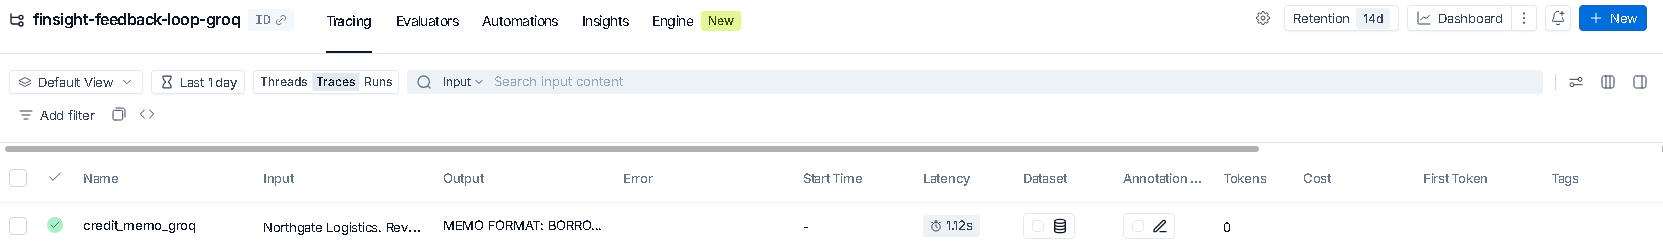